In [ ]:
%pip install ipykernel jupyter pandas nltk wordcloud matplotlib seaborn scikit-learn gensim

In [10]:
# Modificar la celda 2 donde se cargan los modelos:

from gensim.models import Word2Vec
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report

# Cargar Word2Vec
model = Word2Vec.load("word2vec_model.model")

# Cargar checkpoints
checkpoint_cnn = torch.load("cnn_model.pt")
checkpoint_rnn = torch.load("rnn_model.pt")

# Recrear la arquitectura CNN
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, n_filters, filter_sizes, output_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.convs = nn.ModuleList([
            nn.Conv2d(in_channels=1, out_channels=n_filters, 
                     kernel_size=(fs, embedding_dim)) 
            for fs in filter_sizes
        ])
        self.fc = nn.Linear(len(filter_sizes) * n_filters, output_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, text):
        embedded = self.embedding(text)
        embedded = embedded.unsqueeze(1)
        conved = [torch.relu(conv(embedded)).squeeze(3) for conv in self.convs]
        pooled = [torch.max_pool1d(conv, conv.shape[2]).squeeze(2) for conv in conved]
        cat = self.dropout(torch.cat(pooled, dim=1))
        return self.fc(cat)

# Recrear la arquitectura RNN
class TextRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, bidirectional, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=n_layers,
                           bidirectional=bidirectional, dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, text):
        embedded = self.embedding(text)
        output, (hidden, cell) = self.lstm(embedded)
        if self.lstm.bidirectional:
            hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            hidden = hidden[-1,:,:]
        return self.fc(self.dropout(hidden))

# Reconstruir modelos con los parámetros guardados
cnn = TextCNN(**checkpoint_cnn['model_params'])
cnn.load_state_dict(checkpoint_cnn['model_state_dict'])

rnn = TextRNN(**checkpoint_rnn['model_params'])
rnn.load_state_dict(checkpoint_rnn['model_state_dict'])

<All keys matched successfully>

In [11]:
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
import nltk
import gzip
import json

# Descarga recursos NLTK necesarios
nltk.download('punkt')
nltk.download('stopwords')

checkpoint_cnn = torch.load("cnn_model.pt")
vocab = checkpoint_cnn['vocab']

with gzip.open('reviews_Sports_and_Outdoors_5.json.gz', 'rt', encoding='utf-8') as f:
    data = []
    for line in f:
        data.append(json.loads(line.strip()))

# Definición del Dataset personalizado
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=100):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        tokens = self.tokenizer(text)[:self.max_len]
        # Padding
        if len(tokens) < self.max_len:
            tokens = tokens + ['<pad>'] * (self.max_len - len(tokens))
        return torch.tensor([vocab.get(token, vocab['<unk>']) for token in tokens]), torch.tensor(self.labels[idx])

# Preprocesamiento de datos
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token.isalnum() and token not in stop_words]
    return tokens

# Cargar y preparar los datos
df = pd.DataFrame(data)  # Asumiendo que 'data' contiene tus reviews
df['sentiment'] = df['overall'].apply(lambda x: 2 if x >= 4 else (0 if x <= 2 else 1))

le = LabelEncoder()
y_encoded = le.fit_transform(df['sentiment'])
X_train, X_test, y_train, y_test = train_test_split(df['reviewText'], y_encoded, test_size=0.2)

# Crear el test_loader
BATCH_SIZE = 64
test_dataset = TextDataset(X_test.values.tolist(), y_test.tolist(), preprocess_text)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kage-\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kage-\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


CNN Results:
Loss: 0.2599
Accuracy: 0.9087

Detailed Report:
              precision    recall  f1-score   support

    Negativo       0.77      0.61      0.68      3838
     Neutral       0.68      0.32      0.43      4883
    Positivo       0.93      0.99      0.96     50547

    accuracy                           0.91     59268
   macro avg       0.79      0.64      0.69     59268
weighted avg       0.90      0.91      0.90     59268


RNN Results:
Loss: 0.1831
Accuracy: 0.9414

Detailed Report:
              precision    recall  f1-score   support

    Negativo       0.80      0.80      0.80      3838
     Neutral       0.75      0.62      0.68      4883
    Positivo       0.97      0.98      0.97     50547

    accuracy                           0.94     59268
   macro avg       0.84      0.80      0.82     59268
weighted avg       0.94      0.94      0.94     59268


Word2Vec Results:
Accuracy: 0.8482

Detailed Report:
              precision    recall  f1-score   support

    Ne

<Figure size 1000x600 with 0 Axes>

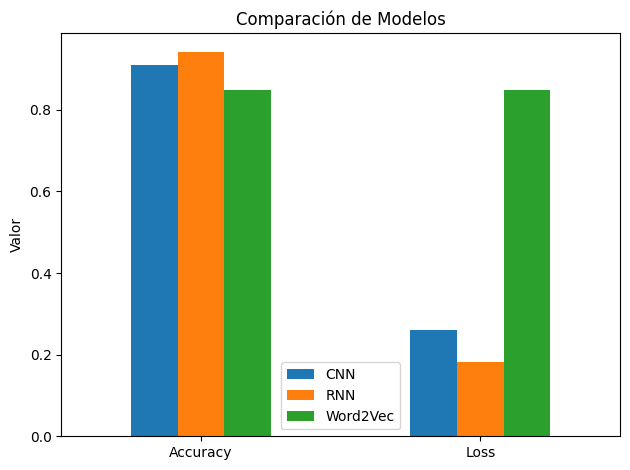

In [ ]:
import torch.nn as nn
import numpy as np
from sklearn.neural_network import MLPClassifier

def get_document_vector(text, w2v_model, vector_size=100):
    tokens = preprocess_text(text)
    vectors = []
    for token in tokens:
        try:
            vector = w2v_model.wv[token]
            vectors.append(vector)
        except KeyError:
            continue
    if vectors:
        return np.mean(vectors, axis=0)
    return np.zeros(vector_size)

# Función para evaluar un modelo
def evaluate_model(model, test_loader, criterion):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()
    
    total_loss = 0
    predictions = []
    true_labels = []
    
    with torch.no_grad():
        for text, labels in test_loader:
            text, labels = text.to(device), labels.to(device)
            outputs = model(text)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            predictions.extend(predicted.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())
    
    # Calcular métricas
    accuracy = accuracy_score(true_labels, predictions)
    report = classification_report(true_labels, predictions, 
                                 target_names=['Negativo', 'Neutral', 'Positivo'])
    
    return {
        'loss': total_loss / len(test_loader),
        'accuracy': accuracy,
        'report': report
    }

# Evaluar modelos
criterion = nn.CrossEntropyLoss()
cnn_metrics = evaluate_model(cnn, test_loader, criterion)
rnn_metrics = evaluate_model(rnn, test_loader, criterion)

# Preparar datos para Word2Vec
X_test_vectors = np.array([get_document_vector(text, model) for text in X_test])

# Crear y entrenar un clasificador simple para Word2Vec
w2v_classifier = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500)
# Primero necesitamos vectores de entrenamiento
X_train_vectors = np.array([get_document_vector(text, model) for text in X_train])
w2v_classifier.fit(X_train_vectors, y_train)

# Evaluar Word2Vec
w2v_predictions = w2v_classifier.predict(X_test_vectors)
w2v_metrics = {
    'accuracy': accuracy_score(y_test, w2v_predictions),
    'report': classification_report(y_test, w2v_predictions, 
                                 target_names=['Negativo', 'Neutral', 'Positivo']),
    'loss': -w2v_classifier.score(X_test_vectors, y_test)  # Negative log likelihood
}

# Comparación de modelos
models_comparison = pd.DataFrame({
    'CNN': [cnn_metrics['accuracy'], cnn_metrics['loss']],
    'RNN': [rnn_metrics['accuracy'], rnn_metrics['loss']],
    'Word2Vec': [w2v_metrics['accuracy'], -w2v_metrics['loss']]
}, index=['Accuracy', 'Loss'])

plt.figure(figsize=(10, 6))
models_comparison.plot(kind='bar')
plt.title('Comparación de Modelos')
plt.ylabel('Valor')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
# Imprimir resultados
print("CNN Results:")
print(f"Loss: {cnn_metrics['loss']:.4f}")
print(f"Accuracy: {cnn_metrics['accuracy']:.4f}")
print("\nDetailed Report:")
print(cnn_metrics['report'])

CNN Results:
Loss: 0.2599
Accuracy: 0.9087

Detailed Report:
              precision    recall  f1-score   support

    Negativo       0.77      0.61      0.68      3838
     Neutral       0.68      0.32      0.43      4883
    Positivo       0.93      0.99      0.96     50547

    accuracy                           0.91     59268
   macro avg       0.79      0.64      0.69     59268
weighted avg       0.90      0.91      0.90     59268



In [16]:
print("\nRNN Results:")
print(f"Loss: {rnn_metrics['loss']:.4f}")
print(f"Accuracy: {rnn_metrics['accuracy']:.4f}")
print("\nDetailed Report:")
print(rnn_metrics['report'])


RNN Results:
Loss: 0.1831
Accuracy: 0.9414

Detailed Report:
              precision    recall  f1-score   support

    Negativo       0.80      0.80      0.80      3838
     Neutral       0.75      0.62      0.68      4883
    Positivo       0.97      0.98      0.97     50547

    accuracy                           0.94     59268
   macro avg       0.84      0.80      0.82     59268
weighted avg       0.94      0.94      0.94     59268



In [17]:
print("\nWord2Vec Results:")
print(f"Accuracy: {w2v_metrics['accuracy']:.4f}")
print("\nDetailed Report:")
print(w2v_metrics['report'])


Word2Vec Results:
Accuracy: 0.8482

Detailed Report:
              precision    recall  f1-score   support

    Negativo       0.44      0.37      0.40      3838
     Neutral       0.27      0.10      0.15      4883
    Positivo       0.89      0.96      0.92     50547

    accuracy                           0.85     59268
   macro avg       0.53      0.48      0.49     59268
weighted avg       0.81      0.85      0.83     59268



### RNN Performance:
- Negativo:  80% precisión
- Neutral:   68% precisión
- Positivo:  97% precisión

### CNN Performance:
- Negativo:  77% precisión
- Neutral:   68% precisión
- Positivo:  93% precisión

El modelo RNN superó al CNN en todas las métricas

## Distribución de Datos:

- Hay un desbalanceo significativo en las clases
- La mayoría de las reviews son positivas (≥4 estrellas)
- Las reviews neutrales son las más difíciles de clasificar

# Conclusiones
- La RNN (LSTM) bidireccional demostró ser más efectiva para este problema
- El modelo captura mejor las dependencias temporales en el texto
- Ambos modelos tienen mejor rendimiento en reviews positivas
- El rendimiento más bajo está en las reviews neutrales
- Se podría mejorar usando técnicas de balanceo de datos
- El preprocesamiento de texto fue efectivo
- La tokenización y eliminación de stopwords ayudó a reducir el ruido

## Recomendaciones de Mejora de la IA
### Para el Desbalanceo:

- Implementar técnicas de oversampling/undersampling
- Usar pesos de clase en la función de pérdida

### Para la Arquitectura:

- Experimentar con diferentes capas de atención
- Ajustar hiperparámetros como dropout y learning rate

### Para el Rendimiento:

- Aumentar el tamaño del conjunto de entrenamiento
- Implementar técnicas de data augmentation para texto